In [8]:
import os
import torch

os.makedirs("/content/hc18_work", exist_ok=True)
os.chdir("/content/hc18_work")

EPOCHS = 10
print("GPU available:", torch.cuda.is_available())

GPU available: True


In [2]:
import numpy as np, cv2, torch, torch.nn as nn

IMG = 256
PROC, MODELS, RESULTS = "processed", "models", "results"

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- 1) Kharabiyan (purani machine jaisi images banane ke liye) ----------
def _gauss(x, s, rng):
    return np.clip(x + rng.normal(0, s, x.shape), 0, 1).astype(np.float32)

def _speckle(x, s, rng):
    return np.clip(x * (1 + rng.normal(0, s, x.shape)), 0, 1).astype(np.float32)

def _blur(x, s, rng):
    return x if s == 0 else cv2.GaussianBlur(x, (0, 0), s)

def _contrast(x, f, rng):
    m = x.mean()
    return np.clip((x - m) * f + m, 0, 1).astype(np.float32)

def _lowres(x, f, rng):
    if f == 1:
        return x
    h, w = x.shape
    small = cv2.resize(x, (max(8, int(w / f)), max(8, int(h / f))), interpolation=cv2.INTER_AREA)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)

DEGRADATIONS = {
    "gaussian_noise": (_gauss,    [0, 0.05, 0.10, 0.20, 0.30]),
    "speckle_noise":  (_speckle,  [0, 0.10, 0.20, 0.40, 0.60]),
    "blur":           (_blur,     [0, 1, 2, 4, 6]),
    "low_contrast":   (_contrast, [1.0, 0.7, 0.5, 0.3, 0.15]),
    "low_resolution": (_lowres,   [1, 2, 4, 6, 8]),
}

def degrade_batch(X, kind, level, seed=0):
    fn = DEGRADATIONS[kind][0]
    rng = np.random.default_rng(seed)
    return np.stack([fn(x, level, rng) for x in X])

# ---------- 2) U-Net model ----------
def block(i, o):
    return nn.Sequential(
        nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(True),
        nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(True))

class UNet(nn.Module):
    def __init__(self, base=16):
        super().__init__()
        c = [base, base*2, base*4, base*8, base*16]
        self.enc = nn.ModuleList([block(1, c[0]), block(c[0], c[1]), block(c[1], c[2]), block(c[2], c[3])])
        self.pool = nn.MaxPool2d(2)
        self.mid = block(c[3], c[4])
        self.up = nn.ModuleList([nn.ConvTranspose2d(c[i+1], c[i], 2, stride=2) for i in [3, 2, 1, 0]])
        self.dec = nn.ModuleList([block(c[i]*2, c[i]) for i in [3, 2, 1, 0]])
        self.out = nn.Conv2d(c[0], 1, 1)

    def forward(self, x):
        skips = []
        for e in self.enc:
            x = e(x); skips.append(x); x = self.pool(x)
        x = self.mid(x)
        for up, dec, s in zip(self.up, self.dec, reversed(skips)):
            x = dec(torch.cat([s, up(x)], 1))
        return self.out(x)

# ---------- 3) Helper functions ----------
def load_model(path, device=None):
    device = device or get_device()
    m = UNet().to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    return m.eval()

@torch.no_grad()
def predict(model, X, device=None, bs=32):
    device = device or get_device()
    model.eval(); out = []
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i+bs]).unsqueeze(1).to(device)
        out.append(torch.sigmoid(model(xb)).squeeze(1).cpu().numpy())
    return np.concatenate(out)

def dice_scores(P, Y, eps=1e-6):
    P = P.astype(np.float32); Y = Y.astype(np.float32)
    inter = (P * Y).sum((1, 2))
    return (2*inter + eps) / (P.sum((1, 2)) + Y.sum((1, 2)) + eps)

def hc_from_mask(mask, w, h, pixel_mm):
    m = cv2.resize(mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return np.nan
    c = max(cnts, key=cv2.contourArea)
    if len(c) < 5:
        return np.nan
    (_, _), (d1, d2), _ = cv2.fitEllipse(c)
    a, b = d1/2, d2/2
    return float(np.pi * (3*(a+b) - np.sqrt((3*a+b)*(a+3*b))) * pixel_mm)

In [4]:
import glob, shutil, subprocess
R = "data/HC18"; os.makedirs(R, exist_ok=True)
base = "https://zenodo.org/records/1327317/files"

if not os.path.exists(f"{R}/training_set.zip"):
    subprocess.run(f"wget -q -O {R}/training_set.zip '{base}/training_set.zip?download=1'", shell=True)
if not os.path.exists(f"{R}/training_set_pixel_size_and_HC.csv"):
    subprocess.run(f"wget -q -O {R}/training_set_pixel_size_and_HC.csv '{base}/training_set_pixel_size_and_HC.csv?download=1'", shell=True)

if not glob.glob(f"{R}/training_set/*_HC.png"):
    subprocess.run(f"unzip -q -o {R}/training_set.zip -d {R}/tmp", shell=True)
    os.makedirs(f"{R}/training_set", exist_ok=True)
    for f in glob.glob(f"{R}/tmp/**/*.png", recursive=True):
        shutil.move(f, f"{R}/training_set/" + os.path.basename(f))

print("images:", len(glob.glob(f"{R}/training_set/*_HC.png")),
      "| annotations:", len(glob.glob(f"{R}/training_set/*_HC_Annotation.png")))

images: 806 | annotations: 806


In [5]:
ROOT = "data/HC18"
df = pd.read_csv(f"{ROOT}/training_set_pixel_size_and_HC.csv") if "pd" in globals() else None
import pandas as pd
df = pd.read_csv(f"{ROOT}/training_set_pixel_size_and_HC.csv")
df.columns = ["filename", "pixel_size", "hc"]

X, Y, H, W = [], [], [], []
for fn in df.filename:
    img = cv2.imread(f"{ROOT}/training_set/{fn}", 0)
    ann = cv2.imread(f"{ROOT}/training_set/{fn.replace('.png', '_Annotation.png')}", 0)
    h, w = img.shape
    cnts, _ = cv2.findContours((ann > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    mask = np.zeros_like(ann, dtype=np.uint8)
    cv2.drawContours(mask, cnts, -1, 1, -1)
    X.append(cv2.resize(img, (IMG, IMG), interpolation=cv2.INTER_AREA))
    Y.append(cv2.resize(mask, (IMG, IMG), interpolation=cv2.INTER_NEAREST))
    H.append(h); W.append(w)

df["orig_h"], df["orig_w"] = H, W

pid = df.filename.str.split("_").str[0]
ids = np.array(sorted(pid.unique()))
np.random.default_rng(42).shuffle(ids)
n = len(ids)
tr, va = set(ids[:int(.7*n)]), set(ids[int(.7*n):int(.85*n)])
df["split"] = ["train" if p in tr else "val" if p in va else "test" for p in pid]

os.makedirs(PROC, exist_ok=True)
np.savez_compressed(f"{PROC}/data.npz", X=np.stack(X), Y=np.stack(Y), split=df.split.values.astype(str))
df.to_csv(f"{PROC}/meta.csv", index=False)
print(df.split.value_counts())

split
train    711
test     145
val      143
Name: count, dtype: int64


In [9]:
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

_d = np.load(f"{PROC}/data.npz")
X_all = _d["X"].astype(np.float32) / 255.0
Y_all = _d["Y"].astype(np.float32)
SP = _d["split"]

class DS(Dataset):
    def __init__(self, X, Y, augment, seed):
        self.X, self.Y, self.aug = X, Y, augment
        self.rng = np.random.default_rng(seed)
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x, y = self.X[i].copy(), self.Y[i].copy()
        if self.rng.random() < 0.5:                       # random flip
            x, y = x[:, ::-1].copy(), y[:, ::-1].copy()
        if self.aug and self.rng.random() < 0.7:          # random kharabi
            kind = self.rng.choice(list(DEGRADATIONS))
            fn, levels = DEGRADATIONS[kind]
            x = fn(x, levels[self.rng.integers(1, len(levels))], self.rng)
        return torch.from_numpy(x).unsqueeze(0), torch.from_numpy(y).unsqueeze(0)

def loss_fn(logits, y):
    bce = F.binary_cross_entropy_with_logits(logits, y)
    p = torch.sigmoid(logits)
    dice = 1 - (2*(p*y).sum() + 1) / (p.sum() + y.sum() + 1)
    return bce + dice

def train(name, augment=False, seed=0, epochs=EPOCHS, bs=16):
    torch.manual_seed(seed); np.random.seed(seed)
    dev = get_device()
    tr = DataLoader(DS(X_all[SP=="train"], Y_all[SP=="train"], augment, seed), batch_size=bs, shuffle=True)
    Xv, Yv = X_all[SP=="val"], Y_all[SP=="val"]
    model = UNet().to(dev)
    opt = torch.optim.Adam(model.parameters(), 1e-3)
    os.makedirs(MODELS, exist_ok=True); best = 0
    for ep in range(epochs):
        model.train(); tot = 0
        for xb, yb in tr:
            xb, yb = xb.to(dev), yb.to(dev)
            loss = loss_fn(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item()
        v = dice_scores(predict(model, Xv, dev) > 0.5, Yv).mean()
        print(f"[{name}] epoch {ep+1}/{epochs}  loss {tot/len(tr):.4f}  val_dice {v:.4f}")
        if v > best:
            best = v; torch.save(model.state_dict(), f"{MODELS}/{name}.pt")
    print(f"[{name}] best val dice: {best:.4f}\n")

In [10]:
train("baseline", augment=False, seed=0)

[baseline] epoch 1/10  loss 0.8605  val_dice 0.8768
[baseline] epoch 2/10  loss 0.5295  val_dice 0.9150
[baseline] epoch 3/10  loss 0.3765  val_dice 0.9327
[baseline] epoch 4/10  loss 0.2787  val_dice 0.9389
[baseline] epoch 5/10  loss 0.2215  val_dice 0.9299
[baseline] epoch 6/10  loss 0.1830  val_dice 0.9548
[baseline] epoch 7/10  loss 0.1532  val_dice 0.9553
[baseline] epoch 8/10  loss 0.1426  val_dice 0.9545
[baseline] epoch 9/10  loss 0.1309  val_dice 0.9547
[baseline] epoch 10/10  loss 0.1185  val_dice 0.9424
[baseline] best val dice: 0.9553



In [11]:
for s in range(3):
    train(f"aug_s{s}", augment=True, seed=s)

[aug_s0] epoch 1/10  loss 0.9430  val_dice 0.8592
[aug_s0] epoch 2/10  loss 0.5957  val_dice 0.8972
[aug_s0] epoch 3/10  loss 0.4113  val_dice 0.9223
[aug_s0] epoch 4/10  loss 0.3003  val_dice 0.9302
[aug_s0] epoch 5/10  loss 0.2445  val_dice 0.9315
[aug_s0] epoch 6/10  loss 0.2008  val_dice 0.8984
[aug_s0] epoch 7/10  loss 0.1686  val_dice 0.9532
[aug_s0] epoch 8/10  loss 0.1568  val_dice 0.9545
[aug_s0] epoch 9/10  loss 0.1399  val_dice 0.9554
[aug_s0] epoch 10/10  loss 0.1318  val_dice 0.9521
[aug_s0] best val dice: 0.9554

[aug_s1] epoch 1/10  loss 0.9572  val_dice 0.8280
[aug_s1] epoch 2/10  loss 0.6343  val_dice 0.8923
[aug_s1] epoch 3/10  loss 0.4619  val_dice 0.9207
[aug_s1] epoch 4/10  loss 0.3517  val_dice 0.9113
[aug_s1] epoch 5/10  loss 0.2755  val_dice 0.9447
[aug_s1] epoch 6/10  loss 0.2256  val_dice 0.9391
[aug_s1] epoch 7/10  loss 0.1925  val_dice 0.9463
[aug_s1] epoch 8/10  loss 0.1621  val_dice 0.9343
[aug_s1] epoch 9/10  loss 0.1443  val_dice 0.9576
[aug_s1] epoch 10

gaussian_noise 0 done
gaussian_noise 0.05 done
gaussian_noise 0.1 done
gaussian_noise 0.2 done
gaussian_noise 0.3 done
speckle_noise 0 done
speckle_noise 0.1 done
speckle_noise 0.2 done
speckle_noise 0.4 done
speckle_noise 0.6 done
blur 0 done
blur 1 done
blur 2 done
blur 4 done
blur 6 done
low_contrast 1.0 done
low_contrast 0.7 done
low_contrast 0.5 done
low_contrast 0.3 done
low_contrast 0.15 done
low_resolution 1 done
low_resolution 2 done
low_resolution 4 done
low_resolution 6 done
low_resolution 8 done


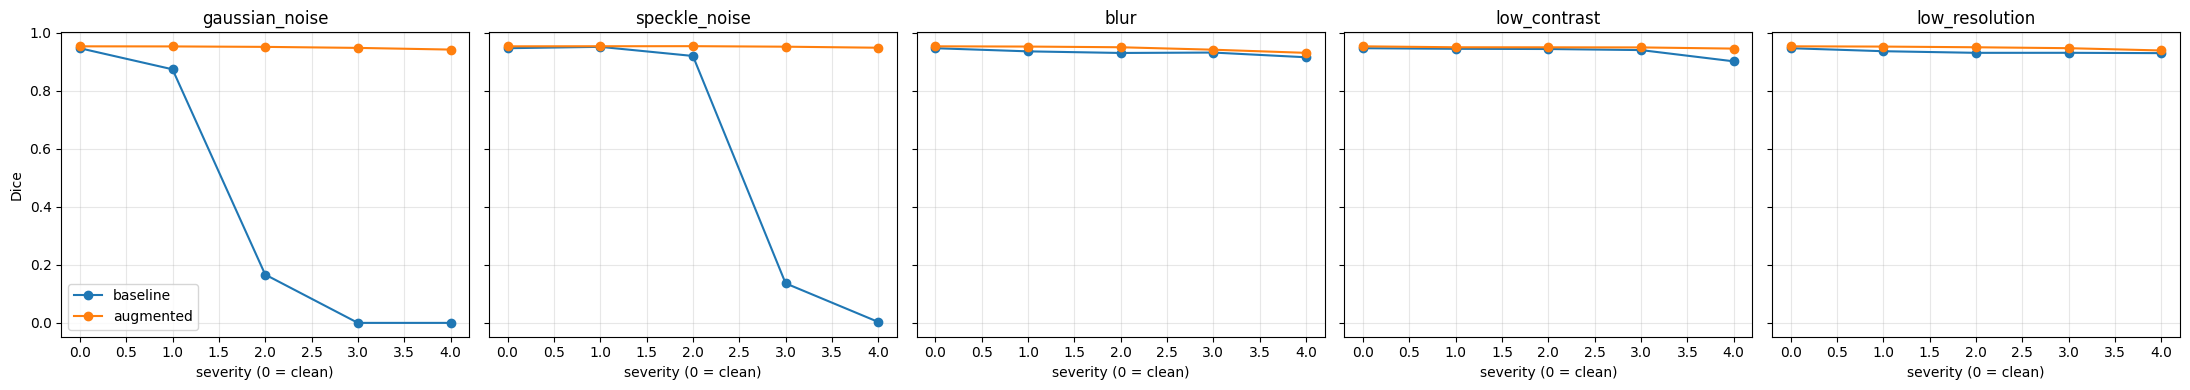

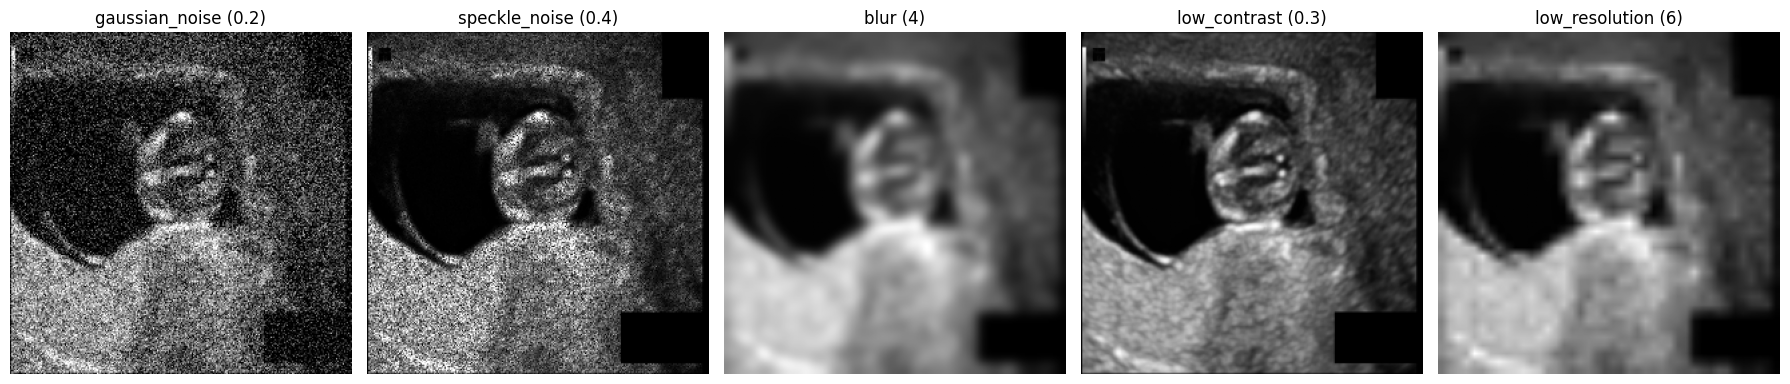

model                    augmented  baseline
degradation    severity                     
blur           0             0.954     0.947
               1             0.953     0.937
               2             0.951     0.931
               3             0.942     0.932
               4             0.931     0.916
gaussian_noise 0             0.954     0.947
               1             0.954     0.875
               2             0.952     0.167
               3             0.949     0.000
               4             0.943     0.000
low_contrast   0             0.954     0.947
               1             0.951     0.945
               2             0.951     0.945
               3             0.950     0.941
               4             0.946     0.902
low_resolution 0             0.954     0.947
               1             0.953     0.937
               2             0.951     0.932
               3             0.948     0.932
               4             0.940     0.930
speckle_no

In [12]:
import matplotlib.pyplot as plt

dev = get_device()
d = np.load(f"{PROC}/data.npz")
sp = d["split"]
Xt = d["X"][sp == "test"].astype(np.float32) / 255.0
Yt = d["Y"][sp == "test"]
models = {"baseline": load_model(f"{MODELS}/baseline.pt"), "augmented": load_model(f"{MODELS}/aug_s0.pt")}

rows = []
for kind, (_, levels) in DEGRADATIONS.items():
    for li, lv in enumerate(levels):
        Xd = degrade_batch(Xt, kind, lv)
        for name, m in models.items():
            dsc = dice_scores(predict(m, Xd, dev) > 0.5, Yt)
            rows.append(dict(degradation=kind, severity=li, level=lv, model=name, dice=dsc.mean(), dice_std=dsc.std()))
        print(kind, lv, "done")

os.makedirs(RESULTS, exist_ok=True)
rdf = pd.DataFrame(rows); rdf.to_csv(f"{RESULTS}/robustness.csv", index=False)

fig, axs = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
for ax, kind in zip(axs, DEGRADATIONS):
    for name in models:
        s = rdf[(rdf.degradation == kind) & (rdf.model == name)]
        ax.plot(s.severity, s.dice, marker="o", label=name)
    ax.set_title(kind); ax.set_xlabel("severity (0 = clean)"); ax.grid(alpha=.3)
axs[0].set_ylabel("Dice"); axs[0].legend()
plt.tight_layout(); plt.savefig(f"{RESULTS}/robustness.png", dpi=150); plt.show()

# kharabiyon ki examples (report ke liye)
fig, axs = plt.subplots(1, 5, figsize=(18, 4))
for ax, (kind, (_, lv)) in zip(axs, DEGRADATIONS.items()):
    ax.imshow(degrade_batch(Xt[:1], kind, lv[3])[0], cmap="gray"); ax.set_title(f"{kind} ({lv[3]})"); ax.axis("off")
plt.tight_layout(); plt.savefig(f"{RESULTS}/degradation_examples.png", dpi=150); plt.show()

print(rdf.pivot_table(index=["degradation", "severity"], columns="model", values="dice").round(3))

uncertainty threshold: 0.04367453
Dice (ensemble): 0.9574
MAE all      : 2.90 mm
MAE unflagged: 2.17 mm  (124 images)
MAE flagged  : 7.18 mm  (21 images)


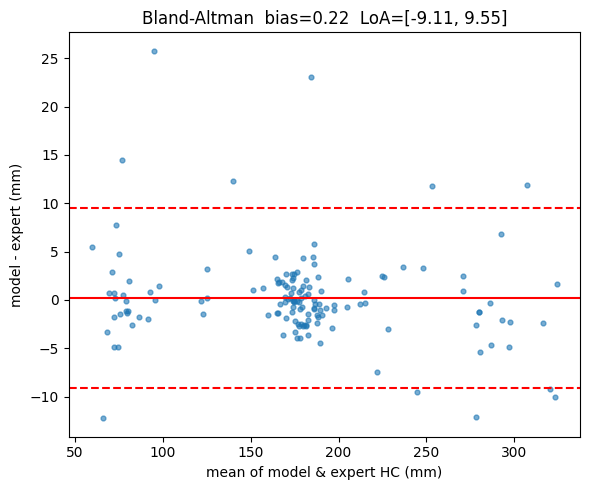

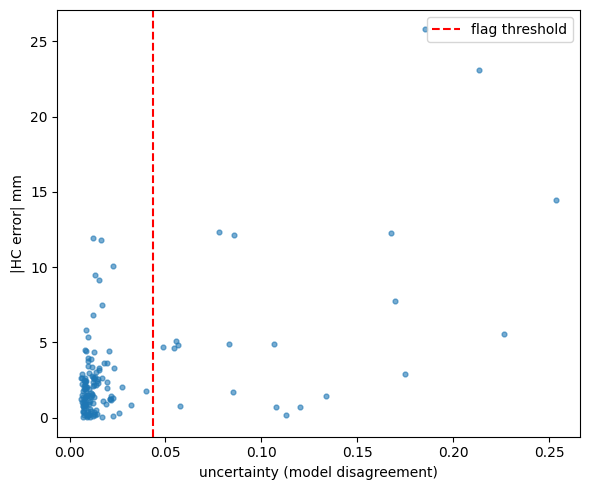

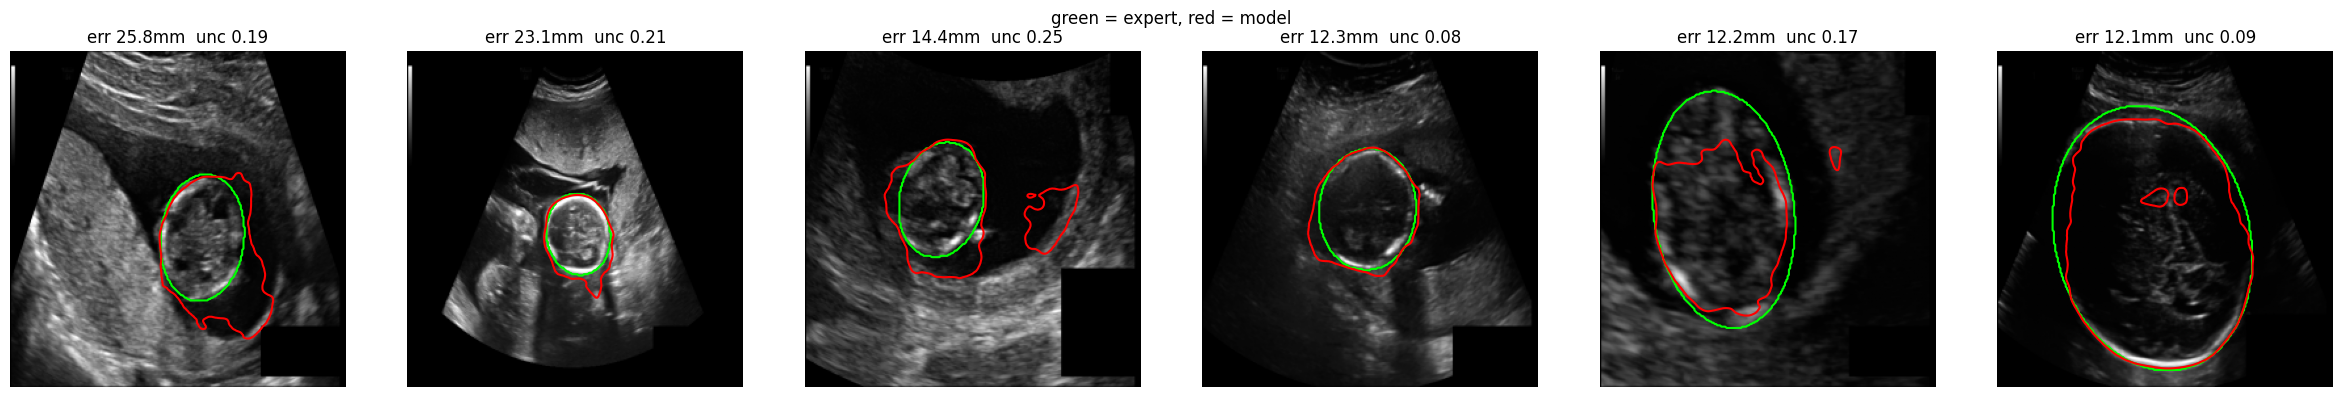

              condition  mean_unc    MAE  pct_flagged
0                 clean     0.028  2.898       14.483
1  gaussian_noise (0.2)     0.034  3.486       17.241
2   speckle_noise (0.4)     0.033  2.909       13.793
3              blur (4)     0.039  4.364       18.621
4    low_contrast (0.3)     0.036  5.144       16.552
5    low_resolution (6)     0.034  4.087       16.552


In [13]:
import itertools

meta = pd.read_csv(f"{PROC}/meta.csv")
Xv, Yv = d["X"][sp == "val"].astype(np.float32) / 255.0, d["Y"][sp == "val"]
mt = meta[meta.split == "test"].reset_index(drop=True)
ens = [load_model(f"{MODELS}/aug_s{i}.pt") for i in range(3)]

def ensemble(X):
    probs = np.stack([predict(m, X, dev) for m in ens])
    mean = probs.mean(0)
    masks = probs > 0.5
    dis = 1 - np.mean([dice_scores(masks[i], masks[j]) for i, j in itertools.combinations(range(3), 2)], axis=0)
    return mean, dis

def hc_all(mean, meta_df):
    return np.array([hc_from_mask(mean[i] > 0.5, r.orig_w, r.orig_h, r.pixel_size) for i, r in meta_df.iterrows()])

# flag ki threshold validation set se (test se nahi!)
_, u_val = ensemble(Xv)
thr = np.percentile(u_val, 90)
print("uncertainty threshold:", thr)

# ---- clean test set ----
mean, unc = ensemble(Xt)
pred_hc, gt_hc = hc_all(mean, mt), mt.hc.values
ok = ~np.isnan(pred_hc)
err = np.abs(pred_hc - gt_hc)
flag = unc > thr
print(f"Dice (ensemble): {dice_scores(mean > .5, Yt).mean():.4f}")
print(f"MAE all      : {np.nanmean(err):.2f} mm")
print(f"MAE unflagged: {np.nanmean(err[~flag]):.2f} mm  ({(~flag).sum()} images)")
print(f"MAE flagged  : {np.nanmean(err[flag]):.2f} mm  ({flag.sum()} images)")

# ---- Bland-Altman ----
diff, avg = (pred_hc - gt_hc)[ok], ((pred_hc + gt_hc) / 2)[ok]
bias, sd = diff.mean(), diff.std()
plt.figure(figsize=(6, 5))
plt.scatter(avg, diff, s=12, alpha=.6)
for y, ls in [(bias, "-"), (bias + 1.96*sd, "--"), (bias - 1.96*sd, "--")]:
    plt.axhline(y, color="r", ls=ls)
plt.xlabel("mean of model & expert HC (mm)"); plt.ylabel("model - expert (mm)")
plt.title(f"Bland-Altman  bias={bias:.2f}  LoA=[{bias-1.96*sd:.2f}, {bias+1.96*sd:.2f}]")
plt.tight_layout(); plt.savefig(f"{RESULTS}/bland_altman.png", dpi=150); plt.show()

# ---- uncertainty vs error ----
plt.figure(figsize=(6, 5))
plt.scatter(unc[ok], err[ok], s=12, alpha=.6); plt.axvline(thr, color="r", ls="--", label="flag threshold")
plt.xlabel("uncertainty (model disagreement)"); plt.ylabel("|HC error| mm"); plt.legend()
plt.tight_layout(); plt.savefig(f"{RESULTS}/uncertainty_vs_error.png", dpi=150); plt.show()

# ---- failure cases: 6 sab se kharab images ----
worst = np.argsort(-np.nan_to_num(err, nan=0))[:6]
fig, axs = plt.subplots(1, 6, figsize=(24, 4))
for ax, i in zip(axs, worst):
    ax.imshow(Xt[i], cmap="gray")
    ax.contour(Yt[i], levels=[.5], colors="lime"); ax.contour(mean[i], levels=[.5], colors="red")
    ax.set_title(f"err {err[i]:.1f}mm  unc {unc[i]:.2f}"); ax.axis("off")
plt.suptitle("green = expert, red = model"); plt.tight_layout()
plt.savefig(f"{RESULTS}/failure_cases.png", dpi=150); plt.show()

# ---- kya kharab images par uncertainty barhti hai? ----
rows = [dict(condition="clean", mean_unc=unc.mean(), MAE=np.nanmean(err), pct_flagged=100*flag.mean())]
for kind, (_, lv) in DEGRADATIONS.items():
    Xd = degrade_batch(Xt, kind, lv[3])
    m2, u2 = ensemble(Xd)
    e2 = np.abs(hc_all(m2, mt) - gt_hc)
    rows.append(dict(condition=f"{kind} ({lv[3]})", mean_unc=u2.mean(), MAE=np.nanmean(e2), pct_flagged=100*(u2 > thr).mean()))
tab = pd.DataFrame(rows).round(3); tab.to_csv(f"{RESULTS}/uncertainty_table.csv", index=False)
print(tab)

In [14]:
from google.colab import files
shutil.make_archive("/content/results_hc18", "zip", RESULTS)
files.download("/content/results_hc18.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>